# AA_Cam_pose_sweeps

Sweeps camera density (target frame count, `cam_poses`) at a fixed video range (`start_3D_recon`..`end_3D_recon`) through every reconstruction technique, scores each against GPS ground truth, and pools everything into one CSV.

Split into two independently-runnable parts:
- **Part 2 (Sweep)** is expensive (minutes per technique per density) and resumable -- safe to interrupt/kill and re-run from the top. GPU OOM kills the whole kernel outright (not a catchable Python exception), so the resumability design is disk-based, not in-process: see the markdown cell above Part 2.
- **Part 3 (Load + plot)** is cheap -- it only reads the pooled CSV off disk, so the chart can be restyled/re-run any number of times without re-touching the sweep.

Reuses `align_and_score` and the trace loaders verbatim from `AA_Cam_pose_estimate_batches.ipynb`.

In [20]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## Config

In [ ]:
import sys
import gc
import time
from datetime import datetime, timezone
from pathlib import Path

import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt

# Find the repo root by walking up until we hit src/A_Config.py -- see
# AA_Cam_pose_estimate_batches.ipynb for why this is more robust than Path.cwd().parent.
project_root = Path.cwd()
while not (project_root / "src" / "A_Config.py").exists():
    if project_root == project_root.parent:
        raise RuntimeError("couldn't find repo root (src/A_Config.py) above cwd")
    project_root = project_root.parent
sys.path.insert(0, str(project_root / "src"))
print("project_root:", project_root)

from A_Config import (
    set_case, case_dir, cut3r_output_dir, vggt_o_output_dir, predictions_path,
    lingbot_map_dir, frames_for_cam_poses_dir, FRAME_NAME_FMT,
)
from B_video_processing import image_sequencer, video_fps, available_frames
from run_models.E_cut3r_recon import run_cut3r
from run_models.E_VGGT_omega import run_vggt_omega
from run_models.E_megasam_recon import run_megasam
from run_models.B_lingbot_map import run_lingbot_map
from F_post_recon_processing import (
    Reconstruction, load_cut3r_trace_v2, load_megasam_trace, load_VGGT_trace,
    load_lingbot_map_trace,
)
from Q_GPS_processing import csv_to_GPS_dict
from Q_Metric_georeferencing import GPS_camerapose_matcher
from G_transforms_alignments import umeyama_align

case_name = "07_Tropea_cafe"
experiment = "Cat_walk_sweeps"
set_case(case_name, experiment)  # must happen before any case_dir()/A_Config getter call below

source_dir   = case_dir() / "010_source"
videos = list(source_dir.glob("*.mp4"))
video_path = videos[0]


# Fixed video range -- only the frame DENSITY within this range varies across the sweep.
# Hardcoded per AI_coppertest3_vggt.ipynb's precedent (no reusable start/end-frame config exists yet).
start_3D_recon = 1661
end_3D_recon = 8589+72


fps = video_fps(video_path)
print(f"video fps: {fps:.3f}")

# Target frame counts to sweep, ascending -- ascending order matters for the
# OOM-precaution logic below (more frames -> more GPU memory).
CAM_POSES = [50, 75, 100, 125, 150, 175, 200, 225, 250,275,300]

# Fixed run order (user-specified) -- cheapest/most-reliable techniques first.
TECHNIQUE_ORDER = ["CUT3R","CUT3R_Revisit", "lingbot-map", "VGGT-Omega", "MegaSaM", "VGGT"]

# Which techniques are actually enabled -- same defaults as AA_Cam_pose_estimate_batches.ipynb.
FLAGS = {
    "CUT3R":       True,
    "CUT3R_Revisit": True,
    "lingbot-map": True,
    "VGGT-Omega":  True,
    "MegaSaM":     False,
    "VGGT":        False,
}

out_dir = case_dir() / "080_Experiments"
out_dir.mkdir(parents=True, exist_ok=True)
status_path = out_dir / "density_sweep_status.csv"
results_path = out_dir / "density_sweep_results.csv"

project_root: /cs/student/project_msc/2025/cgvi/dbarker
video fps: 29.917


## Reset sweep state

Deletes **only** this sweep's own output -- everything from running this sweep, nothing more, nothing less: every `poses_*` frame/reconstruction folder under the `experiment` tag defined above, plus the status/results CSVs. Nothing from `AA_Cam_pose_estimate_batches.ipynb` (different experiment name) or anything else in the case directory is touched.

Safe by default: with `CONFIRM_DELETE = False` this only prints what it *would* delete. Flip it to `True` and re-run the cell to actually delete.

In [22]:
import shutil

CONFIRM_DELETE = False  # flip to True and re-run this cell to actually delete

# Every stage folder the sweep writes into, scoped to this sweep's own
# experiment tag -- deleting the whole subtree here is equivalent to deleting
# every poses_XXXX folder under it, without having to glob for them individually.
_SWEEP_DIRS = [
    case_dir() / "020_frames_for_cam_poses" / experiment,
    case_dir() / "034_VGGT_output" / experiment,
    case_dir() / "035_CUT3R_output" / experiment,
    case_dir() / "035_VGGT_O_output" / experiment,
    case_dir() / "036_lingbot_map_output" / experiment,
    case_dir() / "036_MEGASAM_output" / experiment,
]
_SWEEP_FILES = [status_path, results_path]

targets_dirs = [d for d in _SWEEP_DIRS if d.exists()]
targets_files = [f for f in _SWEEP_FILES if f.exists()]

if not CONFIRM_DELETE:
    print("CONFIRM_DELETE is False -- dry run only, nothing deleted. Would remove:")
    for d in targets_dirs:
        print(f"  rmtree {d}")
    for f in targets_files:
        print(f"  rm     {f}")
    if not targets_dirs and not targets_files:
        print("  (nothing to delete)")
else:
    for d in targets_dirs:
        shutil.rmtree(d)
        print(f"deleted {d}")
    for f in targets_files:
        f.unlink()
        print(f"deleted {f}")
    print("Sweep state reset.")

CONFIRM_DELETE is False -- dry run only, nothing deleted. Would remove:
  rmtree /cs/student/project_msc/2025/cgvi/dbarker/Data/07_Tropea_cafe/020_frames_for_cam_poses/Cat_walk_sweeps
  rmtree /cs/student/project_msc/2025/cgvi/dbarker/Data/07_Tropea_cafe/035_CUT3R_output/Cat_walk_sweeps
  rmtree /cs/student/project_msc/2025/cgvi/dbarker/Data/07_Tropea_cafe/035_VGGT_O_output/Cat_walk_sweeps
  rmtree /cs/student/project_msc/2025/cgvi/dbarker/Data/07_Tropea_cafe/036_lingbot_map_output/Cat_walk_sweeps
  rm     /cs/student/project_msc/2025/cgvi/dbarker/Data/07_Tropea_cafe/080_Experiments/density_sweep_status.csv
  rm     /cs/student/project_msc/2025/cgvi/dbarker/Data/07_Tropea_cafe/080_Experiments/density_sweep_results.csv


In [23]:
(end_3D_recon - start_3D_recon)

7000

## Ground truth

Same manual GT loading as `AA_Cam_pose_estimate_batches.ipynb` -- see that notebook for the naming-convention caveat.

In [24]:
gt_csv_path = case_dir() / "000_GPS_Data" / "GPS_tags.csv"
GPS_dict = csv_to_GPS_dict(gt_csv_path)
print(f"{len(GPS_dict)} GT anchors loaded from {gt_csv_path.name}")

29 GT anchors loaded from GPS_tags.csv


## Scoring -- `align_and_score` (reused verbatim from `AA_Cam_pose_estimate_batches.ipynb`)

See that notebook's own commentary for why `rmse`/`mean_dist` are the trustworthy numbers and `trajectory_length`/`spatial_extent`/`rmse_cm_per_m` are context only, not ranking criteria.

In [25]:
def trajectory_length(positions):
    return float(np.sum(np.linalg.norm(np.diff(positions, axis=0), axis=1)))


def spatial_extent(positions):
    centroid = positions.mean(axis=0)
    return float(np.sqrt(np.mean(np.sum((positions - centroid) ** 2, axis=1))))


def align_and_score(technique, cam_pose_dict, runtime_minutes):
    GPS_locs, lat_0, lon_0, object_locs = GPS_camerapose_matcher(GPS_dict, cam_pose_dict)
    R, s, t, B_aligned, rmse = umeyama_align(
        GPS_locs, object_locs, label_A="GT", label_B=technique,
        out_path=None,  # no per-iteration PNGs during the sweep -- see plt.close('all') in run_attempt
        anchor_index=0,
    )
    mean_dist = float(np.mean(np.linalg.norm(GPS_locs - B_aligned, axis=1)))
    traj_len = trajectory_length(GPS_locs)
    return {
        "rmse": rmse,
        "mean dist": mean_dist,
        "correspondences": len(GPS_locs),
        "cam poses (n)": len(cam_pose_dict),  # actual reconstructed pose count -- distinct from
                                               # the sweep loop's "cam_poses" (target density), which
                                               # run_attempt sets separately on this same result dict
        "trajectory length (m)": traj_len,
        "spatial_extent": spatial_extent(GPS_locs),
        "rmse cm/m": 100 * rmse / traj_len if traj_len > 0 else float("nan"),
        "runtime (min)": runtime_minutes,
    }

## Resumability infrastructure

A GPU OOM kills the whole kernel -- it does not raise a catchable Python exception. So a `pending` status row is written to disk *before* each risky call starts, not just a result written after it succeeds. On restart, any row still `pending` means the kernel died mid-attempt (presumed OOM); every larger `cam_poses` for that same technique is then preemptively marked `failed`/skipped rather than re-attempted, since more frames means more GPU memory and the same wall will just get hit again.

In [26]:
STATUS_COLUMNS = ["technique", "cam_poses", "status", "error_type", "error_message", "timestamp"]

# Only these error_types are treated as a hard wall that skips future re-runs --
# an OOM at this density will predictably OOM again, so there's no point retrying.
# Any other failure (a code bug, a data-availability issue like too few GT
# correspondences, etc.) is NOT terminal -- it gets retried every time the
# notebook re-runs, until it either succeeds or the underlying bug is fixed.
_TERMINAL_ERROR_TYPES = {"oom", "presumed_oom_kernel_death", "skipped_precautionary"}


def _load_status():
    if status_path.exists():
        # keep_default_na=False: without it, an all-blank column (e.g. every
        # "pending"/"success" row's error_type="") round-trips through CSV as
        # NaN and gets inferred as float64 -- then the next _set_status() call
        # that tries to write a real string into that column crashes.
        return pd.read_csv(status_path, keep_default_na=False, dtype=str)
    return pd.DataFrame(columns=STATUS_COLUMNS)


def _set_status(technique, cam_poses, status, error_type="", error_message=""):
    df = _load_status()
    mask = (df["technique"] == technique) & (df["cam_poses"] == str(cam_poses))
    row = {
        "technique": technique, "cam_poses": str(cam_poses), "status": status,
        "error_type": error_type, "error_message": error_message,
        "timestamp": datetime.now(timezone.utc).isoformat(),
    }
    if mask.any():
        for k, v in row.items():
            df.loc[mask, k] = v
    else:
        df = pd.concat([df, pd.DataFrame([row])], ignore_index=True)
    df.to_csv(status_path, index=False)  # flushed immediately -- this IS the crash-recovery record


def _get_status_row(technique, cam_poses):
    df = _load_status()
    mask = (df["technique"] == technique) & (df["cam_poses"] == str(cam_poses))
    if not mask.any():
        return None
    return df.loc[mask].iloc[0]


def _get_status(technique, cam_poses):
    row = _get_status_row(technique, cam_poses)
    return None if row is None else row["status"]


def _should_skip(technique, cam_poses):
    """Success is always skipped. A failure is only skipped if it was terminal
    (OOM-related) -- an ordinary/code-bug failure keeps being retried on every
    re-run, since nothing about re-running would predictably fail the same way
    once the actual bug is fixed."""
    row = _get_status_row(technique, cam_poses)
    if row is None:
        return False, None
    if row["status"] == "success":
        return True, "success"
    if row["status"] == "failed" and row["error_type"] in _TERMINAL_ERROR_TYPES:
        return True, f"failed ({row['error_type']})"
    return False, None


def _append_result(row):
    if results_path.exists():
        df = pd.concat([pd.read_csv(results_path), pd.DataFrame([row])], ignore_index=True)
    else:
        df = pd.DataFrame([row])
    df.to_csv(results_path, index=False)  # written immediately after every success, not batched


_OOM_MARKERS = ("out of memory", "cuda out of memory", "cudnn_status_alloc_failed", "cublas_status_alloc_failed")


def classify_error(e):
    if hasattr(torch.cuda, "OutOfMemoryError") and isinstance(e, torch.cuda.OutOfMemoryError):
        return "oom"
    if any(m in str(e).lower() for m in _OOM_MARKERS):
        return "oom"
    return "other"


def resolve_stale_pending():
    """Run once at notebook start: a leftover 'pending' row means the kernel died
    mid-attempt last time (almost certainly a GPU OOM) -- nothing ever ran the
    except block that would have recorded a normal failure. Mark it as a presumed
    OOM and preemptively skip every larger cam_poses for that technique."""
    df = _load_status()
    pending = df[df["status"] == "pending"]
    for _, r in pending.iterrows():
        technique, cam_poses = r["technique"], int(r["cam_poses"])
        print(f"[{technique} @ {cam_poses}] kernel died mid-attempt last run -- presumed GPU OOM "
              f"(restart the kernel now if you haven't already)")
        _set_status(technique, cam_poses, "failed", "presumed_oom_kernel_death",
                    "kernel died before status could be resolved")
        for cp in CAM_POSES:
            if cp > cam_poses and _get_status(technique, cp) is None:
                _set_status(technique, cp, "failed", "skipped_precautionary",
                            f"skipped: {technique} OOM'd at cam_poses={cam_poses}")
                print(f"[{technique} @ {cp}] precautionary skip (OOM upstream at cam_poses={cam_poses})")


def run_attempt(technique, cam_poses, run_fn):
    """run_fn() does the actual reconstruction + scoring and returns the
    align_and_score(...) result dict (technique/cam_poses added by this wrapper),
    or raises on a catchable failure."""
    skip, reason = _should_skip(technique, cam_poses)
    if skip:
        print(f"[{technique} @ {cam_poses}] already {reason}, skipping")
        return

    _set_status(technique, cam_poses, "pending")
    try:
        result = run_fn()
        result["technique"] = technique
        result["cam_poses"] = cam_poses
        _append_result(result)
        _set_status(technique, cam_poses, "success")
        print(f"[{technique} @ {cam_poses}] success, rmse={result['rmse']:.3f}")
    except Exception as e:
        error_type = classify_error(e)
        _set_status(technique, cam_poses, "failed", error_type, str(e)[:500])
        print(f"[{technique} @ {cam_poses}] FAILED ({error_type}): {e}")
        if error_type == "oom":
            for cp in CAM_POSES:
                if cp > cam_poses and _get_status(technique, cp) is None:
                    _set_status(technique, cp, "failed", "skipped_precautionary",
                                f"skipped: {technique} OOM'd at cam_poses={cam_poses}")
                    print(f"[{technique} @ {cp}] precautionary skip (OOM upstream at cam_poses={cam_poses})")
    finally:
        plt.close("all")  # umeyama_align/ortho_charts and the trace loaders never close their figures
        gc.collect()
        if torch.cuda.is_available():
            torch.cuda.empty_cache()

## Part 2 -- Sweep (expensive, resumable, run once/rarely)

Each `cam_poses` value gets its own frames/output folders via a nested experiment tag (`f"{experiment}/poses_{cam_poses:04d}"` passed to `set_case`) -- this makes every `A_Config` getter (including `run_lingbot_map`'s, which has no path parameters at all and only reads the zero-arg getters) automatically density-scoped, with no per-function path-wrangling needed.

Safe to interrupt/kill and re-run from the top at any point.

In [27]:
resolve_stale_pending()

for cam_poses in CAM_POSES:
    experiment_tag = f"{experiment}/poses_{cam_poses:04d}"
    set_case(case_name, experiment_tag)

    recon_dur = end_3D_recon - start_3D_recon
    stride_frames = (recon_dur + cam_poses - 1) // cam_poses  # ceil division
    interval_sec = stride_frames / fps

    frames_dir = frames_for_cam_poses_dir()
    if not list(frames_dir.glob("*.jpg")):
        image_sequencer(
            video_path=str(video_path), output_dir=str(frames_dir),
            interval_sec=interval_sec, start_frame=start_3D_recon, end_frame=end_3D_recon,
        )
    else:
        print(f"cam_poses={cam_poses}: frames already present in {frames_dir}, skipping extraction")
    n_frames = len(available_frames(frames_dir, FRAME_NAME_FMT))

    for technique in TECHNIQUE_ORDER:
        if not FLAGS[technique]:
            continue

        if technique == "CUT3R":
            def _run(frames_dir=frames_dir, n_frames=n_frames, stride_frames=stride_frames):
                t0 = time.perf_counter()
                run_cut3r(
                    frames_dir=frames_dir, output_dir=cut3r_output_dir(),
                    ckpt_path=project_root / "Models" / "CUT3R" / "src" / "cut3r_512_dpt_4_64.pth",
                    render_3rdperson=False,
                )
                runtime = (time.perf_counter() - t0) / 60
                _, cam_pose_dict = load_cut3r_trace_v2(cut3r_output_dir() / "camera")
                r = align_and_score("CUT3R", cam_pose_dict, runtime)
                r["n_frames"] = n_frames
                r["recon_interframe_interval"] = stride_frames
                return r
            
        elif technique == "CUT3R_Revisit":
            def _run(frames_dir=frames_dir, n_frames=n_frames, stride_frames=stride_frames):
                t0 = time.perf_counter()
                run_cut3r(
                    frames_dir=frames_dir, output_dir=cut3r_output_dir() / "revisit",
                    ckpt_path=project_root / "Models" / "CUT3R" / "src" / "cut3r_512_dpt_4_64.pth",
                    render_3rdperson=False, revisit=True,
                )
                runtime = (time.perf_counter() - t0) / 60
                _, cam_pose_dict = load_cut3r_trace_v2(cut3r_output_dir() / "revisit" / "camera")
                r = align_and_score("CUT3R_Revisit", cam_pose_dict, runtime)
                r["n_frames"] = n_frames
                r["recon_interframe_interval"] = stride_frames
                return r
            
        elif technique == "lingbot-map":
            def _run(n_frames=n_frames, stride_frames=stride_frames):
                t0 = time.perf_counter()
                run_lingbot_map()
                runtime = (time.perf_counter() - t0) / 60
                _, cam_pose_dict = load_lingbot_map_trace(lingbot_map_dir())
                r = align_and_score("lingbot-map", cam_pose_dict, runtime)
                r["n_frames"] = n_frames
                r["recon_interframe_interval"] = stride_frames
                return r

        elif technique == "VGGT-Omega":
            def _run(frames_dir=frames_dir, n_frames=n_frames, stride_frames=stride_frames):
                gc.collect(); torch.cuda.empty_cache()
                t0 = time.perf_counter()
                run_vggt_omega(
                    image_dir=str(frames_dir), output_dir=str(vggt_o_output_dir()),
                    checkpoint_path=str(project_root / "Models" / "vggt-omega" / "checkpoints"
                                        / "VGGT-Omega-1B-512" / "vggt_omega_1b_512.pt"),
                    vggt_omega_dir=str(project_root / "Models" / "vggt-omega"),
                    image_resolution=256, conf_thres=20.0, max_points=0, show_cam=True,
                )
                runtime = (time.perf_counter() - t0) / 60
                recon = Reconstruction.load(frames_dir, predictions_path(), FRAME_NAME_FMT)
                cam_pose_dict = recon.cam_pos_dict()
                r = align_and_score("VGGT-Omega", cam_pose_dict, runtime)
                r["n_frames"] = n_frames
                r["recon_interframe_interval"] = stride_frames
                return r

        elif technique == "MegaSaM":
            def _run(frames_dir=frames_dir, n_frames=n_frames, stride_frames=stride_frames,
                     experiment_tag=experiment_tag):
                megasam_output_dir = case_dir() / "036_MEGASAM_output" / experiment_tag
                megasam_output_dir.mkdir(parents=True, exist_ok=True)
                t0 = time.perf_counter()
                megasam_npz_path = run_megasam(
                    frames_dir=frames_dir, output_dir=megasam_output_dir,
                    mega_sam_dir=project_root / "Models" / "mega-sam", scene_name=case_name,
                )
                runtime = (time.perf_counter() - t0) / 60
                # frames_dir passed explicitly -- load_megasam_trace's default
                # (frames_for_recon_dir()) points at a different, density-unaware folder.
                _, cam_pose_dict = load_megasam_trace(megasam_npz_path, frames_dir=frames_dir)
                r = align_and_score("MegaSaM", cam_pose_dict, runtime)
                r["n_frames"] = n_frames
                r["recon_interframe_interval"] = stride_frames
                return r

        elif technique == "VGGT":
            def _run(frames_dir=frames_dir, n_frames=n_frames, stride_frames=stride_frames,
                     experiment_tag=experiment_tag):
                import argparse
                sys.path.insert(0, str(project_root / "Models" / "VGGT" / "vggt"))
                from demo_colmap import demo_fn

                vggt_output_dir = case_dir() / "034_VGGT_output" / experiment_tag
                vggt_args = argparse.Namespace(
                    scene_dir=str(case_dir()), image_dir=str(frames_dir), output_dir=str(vggt_output_dir),
                    max_frames=500, load_resolution=128, seed=42, use_ba=False, max_reproj_error=8.0,
                    shared_camera=False, camera_type="SIMPLE_PINHOLE", vis_thresh=0.2, query_frame_num=8,
                    max_query_pts=4096, fine_tracking=True, conf_thres_value=5.0,
                )
                t0 = time.perf_counter()
                demo_fn(vggt_args)
                runtime = (time.perf_counter() - t0) / 60
                _, cam_pose_dict = load_VGGT_trace(vggt_output_dir, frames_dir=frames_dir)
                r = align_and_score("VGGT", cam_pose_dict, runtime)
                r["n_frames"] = n_frames
                r["recon_interframe_interval"] = stride_frames
                return r

        run_attempt(technique, cam_poses, _run)

cam_poses=50: frames already present in /cs/student/project_msc/2025/cgvi/dbarker/Data/07_Tropea_cafe/020_frames_for_cam_poses/Cat_walk_sweeps/poses_0050, skipping extraction
[CUT3R @ 50] already success, skipping
Loading model...
... loading model from /cs/student/project_msc/2025/cgvi/dbarker/Models/CUT3R/src/cut3r_512_dpt_4_64.pth
instantiating : ARCroco3DStereo(ARCroco3DStereoConfig(freeze='encoder',state_size=768,state_pe='2d',pos_embed='RoPE100',rgb_head=True,pose_head=True,patch_embed_cls='PatchEmbedDust3R',img_size=(512,512),head_type='dpt',output_mode='pts3d+pose',depth_mode=('exp',-inf,inf),conf_mode=('exp',1,inf),pose_mode=('exp',-inf,inf),enc_embed_dim=1024,enc_depth=24,enc_num_heads=16,dec_embed_dim=768,dec_depth=12,dec_num_heads=12,landscape_only=False))
<All keys matched successfully>
50 frames  →  /cs/student/project_msc/2025/cgvi/dbarker/Data/07_Tropea_cafe/035_CUT3R_output/Cat_walk_sweeps/poses_0050/revisit


CUT3R:   0%|                                             | 0/50 [00:00<?, ?it/s]/cs/student/project_msc/2025/cgvi/dbarker/Models/CUT3R/src/dust3r/heads/dpt_head.py:217: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=False):
/cs/student/project_msc/2025/cgvi/dbarker/Models/CUT3R/src/dust3r/heads/dpt_head.py:226: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=False):
CUT3R: 100%|████████████████████████████████████| 50/50 [00:03<00:00, 12.90it/s]


Pass 2 (revisiting): re-processing all frames with frozen final state...


revisit: 100%|██████████████████████████████████| 50/50 [00:08<00:00,  5.59it/s]


Revisit pass done. 50 frames in 0.1 min  (0.18 s/frame)
State saved → /cs/student/project_msc/2025/cgvi/dbarker/Data/07_Tropea_cafe/035_CUT3R_output/Cat_walk_sweeps/poses_0050/revisit/cut3r_state.pt
Done. 50 frames in 0.2 min  (0.26 s/frame)
Output: /cs/student/project_msc/2025/cgvi/dbarker/Data/07_Tropea_cafe/035_CUT3R_output/Cat_walk_sweeps/poses_0050/revisit
{1661: array([-8.636853  , -0.83828527, -5.3833337 ], dtype=float32), 1802: array([-9.466403 , -0.9869998, -8.162616 ], dtype=float32), 1943: array([-6.0780053 , -0.67429143, -6.7671223 ], dtype=float32), 2084: array([-12.150736 ,  -0.8897372,  -9.855424 ], dtype=float32), 2225: array([-7.8682914, -0.7329908, -8.232296 ], dtype=float32), 2359: array([-8.613905 , -0.9515676, -7.2490306], dtype=float32), 2507: array([-8.324368  , -0.64937085, -7.1663413 ], dtype=float32), 2645: array([-8.709359 , -0.5964325, -7.7688465], dtype=float32), 2795: array([-10.275804 ,  -0.8039385,  -9.17968  ], dtype=float32), 2936: array([-7.989844 , -

...

Revisit pass done. 270 frames in 0.8 min  (0.18 s/frame)
State saved → /cs/student/project_msc/2025/cgvi/dbarker/Data/07_Tropea_cafe/035_CUT3R_output/Cat_walk_sweeps/poses_0275/revisit/cut3r_state.pt
Done. 270 frames in 1.2 min  (0.26 s/frame)
Output: /cs/student/project_msc/2025/cgvi/dbarker/Data/07_Tropea_cafe/035_CUT3R_output/Cat_walk_sweeps/poses_0275/revisit
{1661: array([-39.66526  ,   2.5841992, 130.19298  ], dtype=float32), 1687: array([-36.23552  ,   3.0130105, 132.87816  ], dtype=float32), 1713: array([-38.9082   ,   2.0953407, 125.71379  ], dtype=float32), 1739: array([-38.13963  ,   2.8507905, 137.6057   ], dtype=float32), 1761: array([-38.04209  ,   1.6705374, 127.81185  ], dtype=float32), 1791: array([-37.310425 ,   2.7070086, 129.79335  ], dtype=float32), 1817: array([-36.12036  ,   3.2975678, 134.80061  ], dtype=float32), 1840: array([-36.20862  ,   3.0732443, 134.08789  ], dtype=float32), 1869: array([-36.66247 ,   2.956543, 145.72772 ], dtype=float32), 1895: array([-3

CUT3R:   0%|                                            | 0/292 [00:00<?, ?it/s]/cs/student/project_msc/2025/cgvi/dbarker/Models/CUT3R/src/dust3r/heads/dpt_head.py:217: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=False):
/cs/student/project_msc/2025/cgvi/dbarker/Models/CUT3R/src/dust3r/heads/dpt_head.py:226: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=False):
CUT3R: 100%|██████████████████████████████████| 292/292 [00:22<00:00, 12.79it/s]


Pass 2 (revisiting): re-processing all frames with frozen final state...


revisit: 100%|████████████████████████████████| 292/292 [00:52<00:00,  5.61it/s]


Revisit pass done. 292 frames in 0.9 min  (0.18 s/frame)
State saved → /cs/student/project_msc/2025/cgvi/dbarker/Data/07_Tropea_cafe/035_CUT3R_output/Cat_walk_sweeps/poses_0300/revisit/cut3r_state.pt
Done. 292 frames in 1.2 min  (0.26 s/frame)
Output: /cs/student/project_msc/2025/cgvi/dbarker/Data/07_Tropea_cafe/035_CUT3R_output/Cat_walk_sweeps/poses_0300/revisit
{1661: array([-44.43366  ,   2.0980024, 131.41943  ], dtype=float32), 1691: array([-42.953995 ,   1.7553377, 135.20767  ], dtype=float32), 1709: array([-46.78636  ,   1.3364654, 135.99419  ], dtype=float32), 1733: array([-44.383656 ,   2.0054421, 136.46527  ], dtype=float32), 1755: array([-44.39519 ,   1.748039, 135.99818 ], dtype=float32), 1781: array([-40.89565  ,   1.2187748, 130.82939  ], dtype=float32), 1805: array([-42.614597 ,   1.6951746, 125.39525  ], dtype=float32), 1829: array([-42.71137  ,   2.2361982, 139.41217  ], dtype=float32), 1853: array([-43.493885,   2.059933, 140.84378 ], dtype=float32), 1877: array([-41.7

## Part 3 -- Load + plot (cheap, re-runnable independently)

Reads `density_sweep_results.csv` fresh from disk -- does not depend on Part 2 having just run, so this cell can be re-run/restyled any number of times without touching the sweep. Colour mapping matches the informal `tab10`-by-insertion-order precedent in `AA_CAM_POSE_COMPARE_01.ipynb` cell 25 (`lingbot_map`, `VGGT_O`, `CUT3R`, `MegaSaM` kept at their original slots; `VGGT` plain wasn't in that precedent, so it reuses the freed `Reality_Scan` slot).

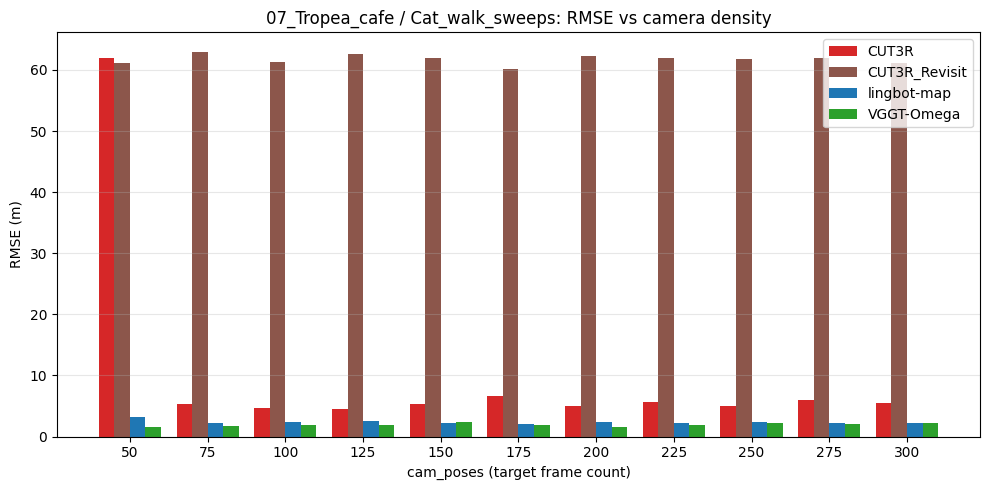

In [31]:
import sys
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

project_root = Path.cwd()
while not (project_root / "src" / "A_Config.py").exists():
    project_root = project_root.parent
sys.path.insert(0, str(project_root / "src"))
from A_Config import set_case, case_dir

case_name = "07_Tropea_cafe"
experiment = "Cat_walk_sweeps"
set_case(case_name, experiment)
results_path = case_dir() / "080_Experiments" / "density_sweep_results.csv"

TECHNIQUE_ORDER = ["CUT3R","CUT3R_Revisit", "lingbot-map", "VGGT-Omega", "MegaSaM", "VGGT"]
tab10 = plt.cm.tab10.colors
COLOR_MAP = {
    "lingbot-map": tab10[0],
    "VGGT":        tab10[1],  # no precedent for plain VGGT -- reuses the freed Reality_Scan slot
    "VGGT-Omega":  tab10[2],
    "CUT3R":       tab10[3],
    "MegaSaM":     tab10[4],
    "CUT3R_Revisit": tab10[5],  # no precedent either -- n
}

df = pd.read_csv(results_path)
techniques = [t for t in TECHNIQUE_ORDER if t in df["technique"].unique()]
cam_poses_vals = sorted(df["cam_poses"].unique())

x = np.arange(len(cam_poses_vals))
width = 0.8 / max(len(techniques), 1)

fig, ax = plt.subplots(figsize=(10, 5))
for i, technique in enumerate(techniques):
    sub = df[df["technique"] == technique].set_index("cam_poses")["rmse"]
    heights = [sub.get(cp, np.nan) for cp in cam_poses_vals]
    ax.bar(x + i * width - 0.4 + width / 2, heights, width, label=technique, color=COLOR_MAP.get(technique))

ax.set_xticks(x)
ax.set_xticklabels(cam_poses_vals)
ax.set_xlabel("cam_poses (target frame count)")
ax.set_ylabel("RMSE (m)")
ax.set_title(f"{case_name} / {experiment}: RMSE vs camera density")
ax.legend()
ax.grid(axis="y", alpha=0.3)
fig.tight_layout()